In [5]:
# Installing libraries
# %pip install pandas numpy scikit-learn opencv-python matplotlib

# Import libraries with desired aliases

In [6]:
import pandas as pd, numpy as np, cv2, matplotlib.pyplot as plt

# Load our dataset

In [7]:
with np.load("mnist_data.npz") as f:
    x_train = f["x_train"][0:5000]/255.0
    y_train = f["y_train"][0:5000]
    x_test = f["x_test"][:500]/255.0
    y_test = f["y_test"][:500]

df = pd.DataFrame(x_train.copy().reshape(5000, 784))
df

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Write the algorithm for the model

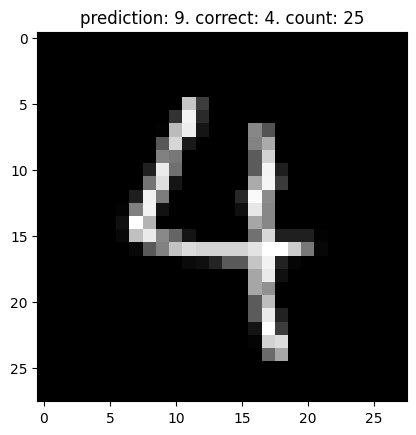

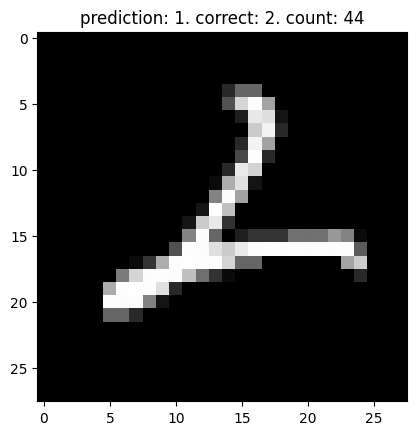

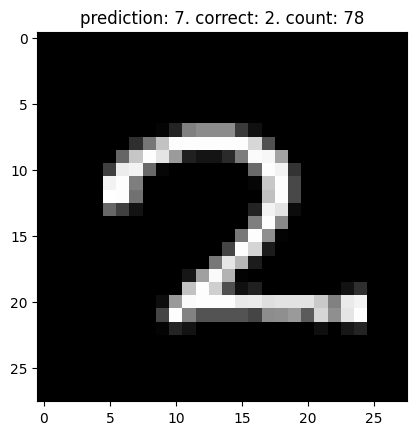

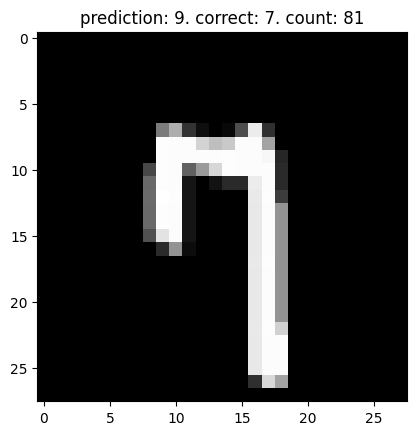

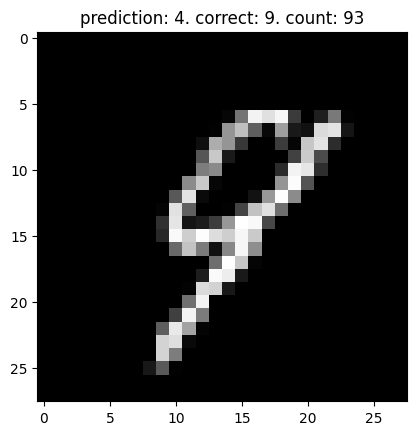

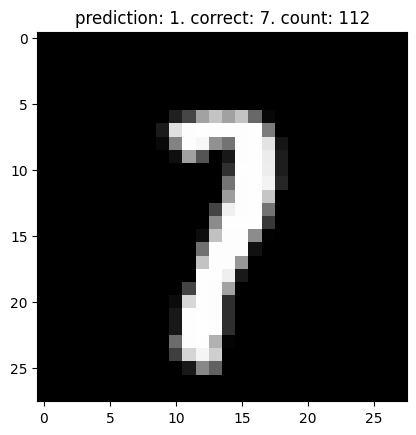

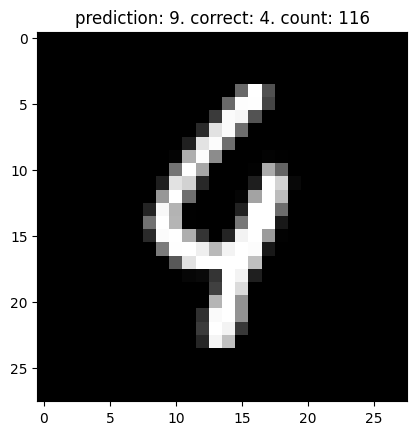

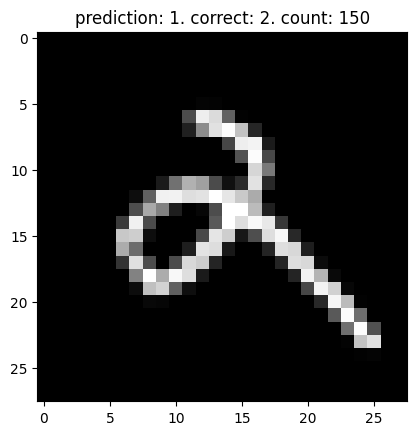

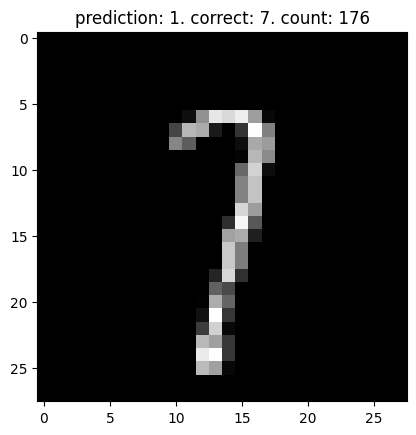

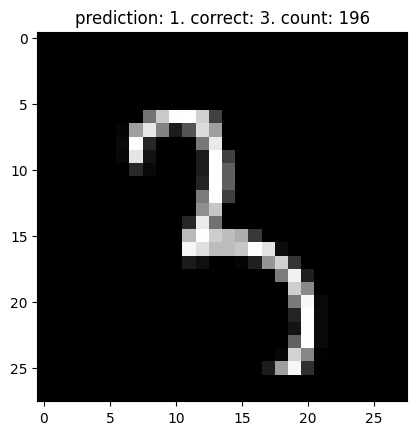

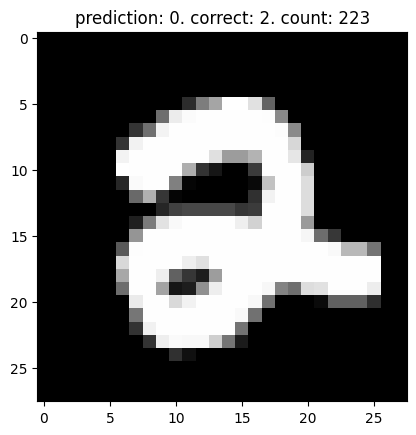

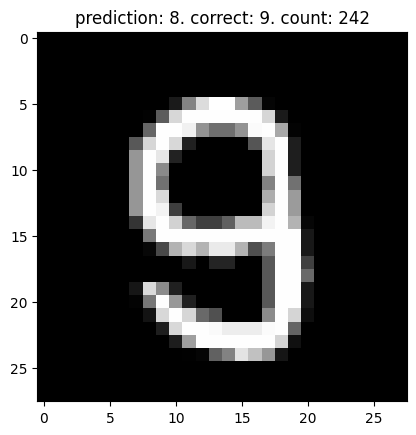

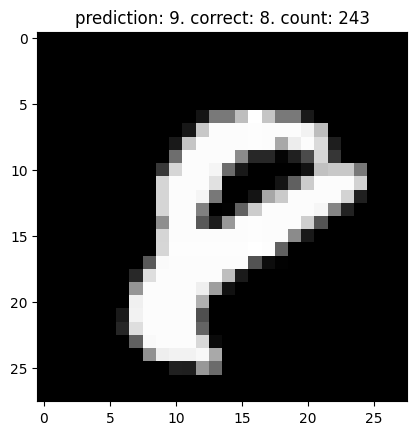

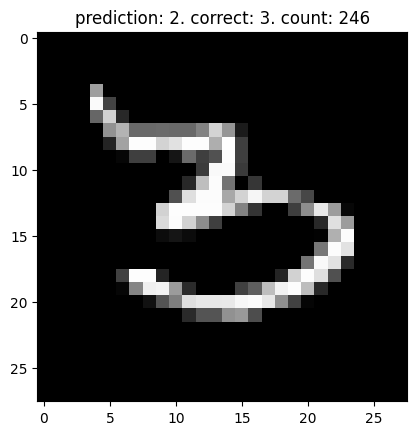

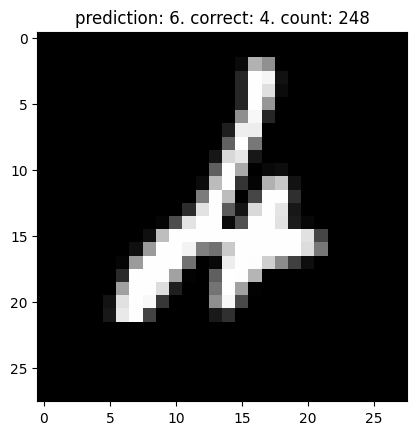

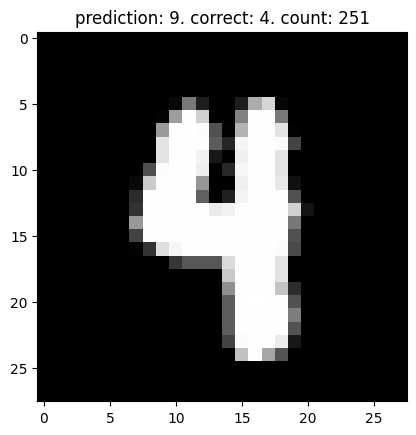

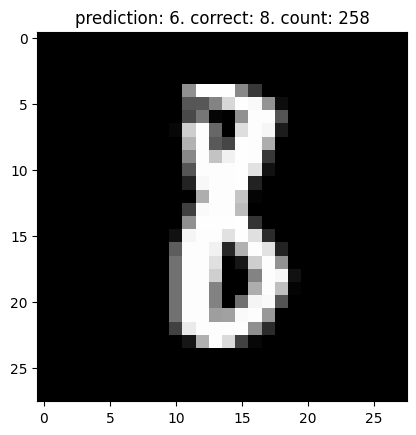

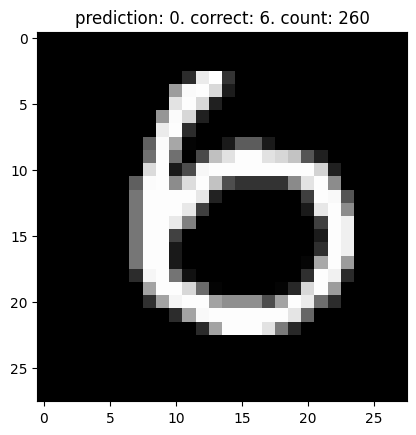

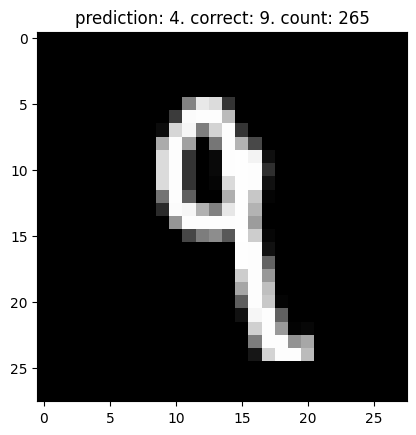

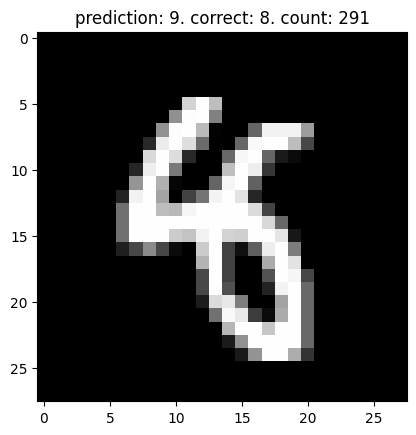

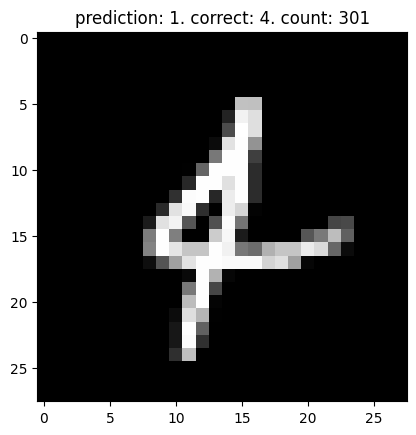

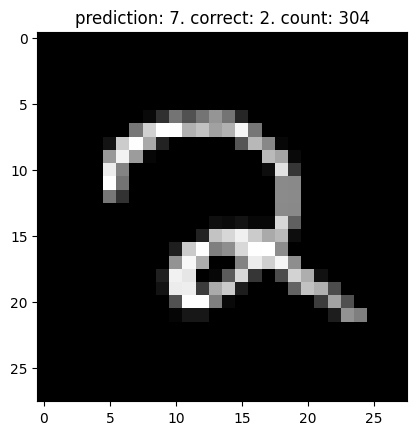

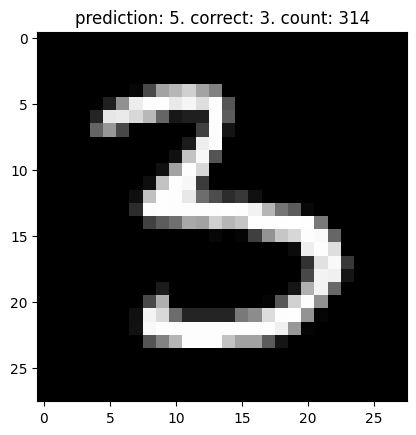

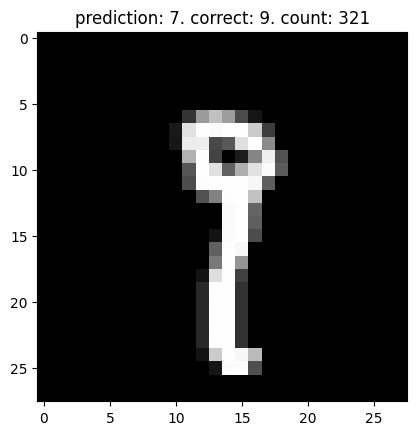

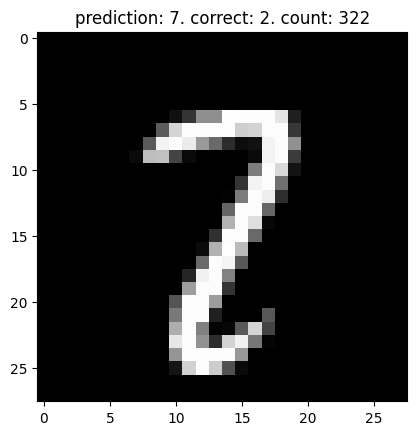

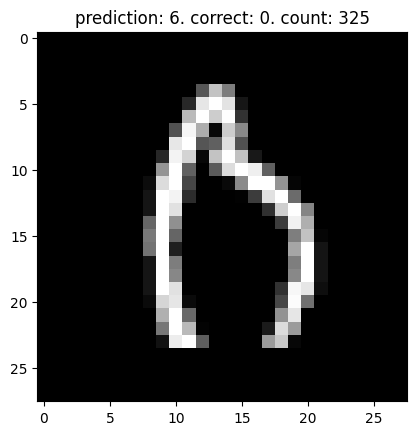

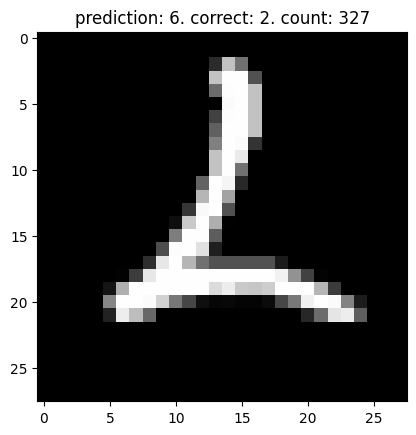

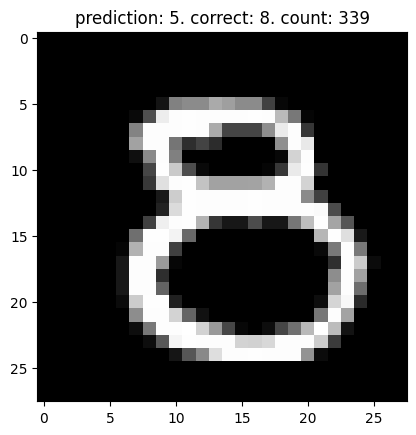

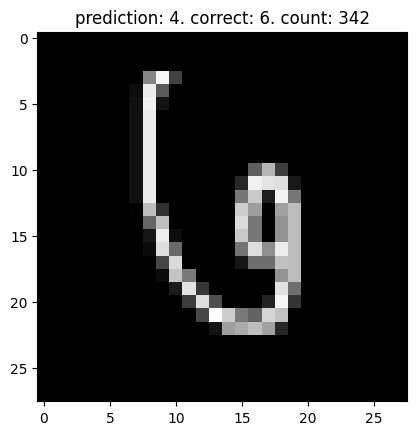

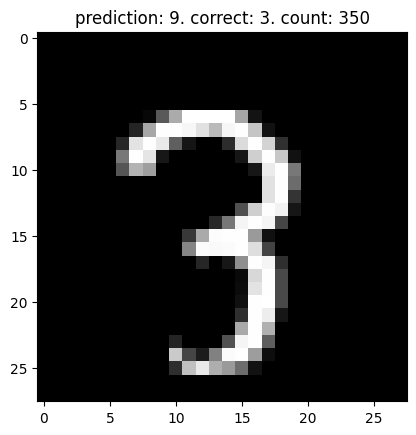

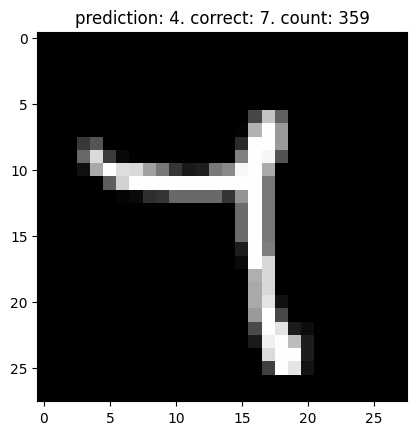

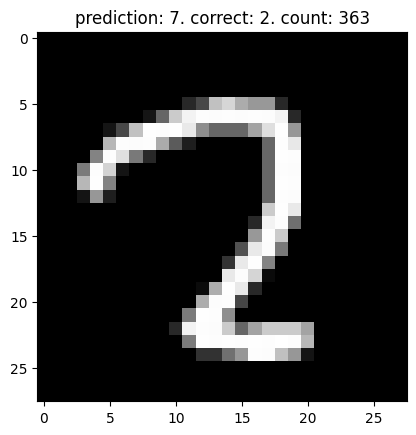

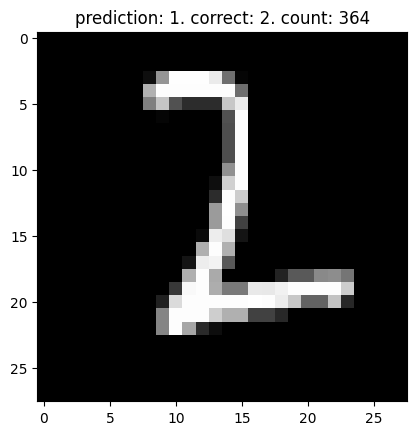

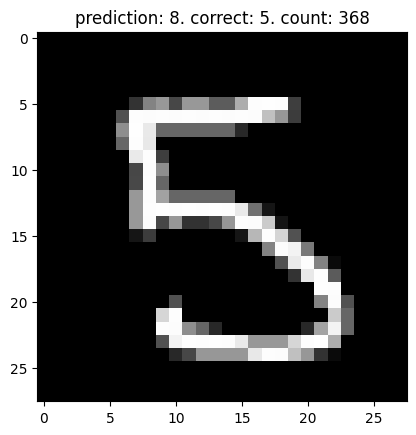

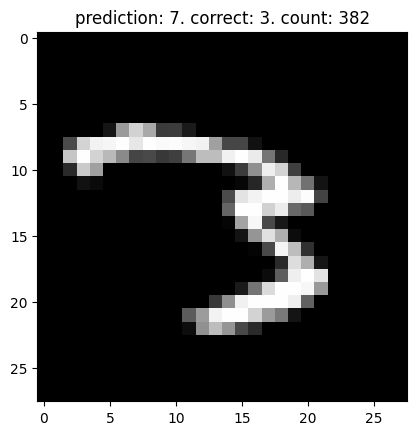

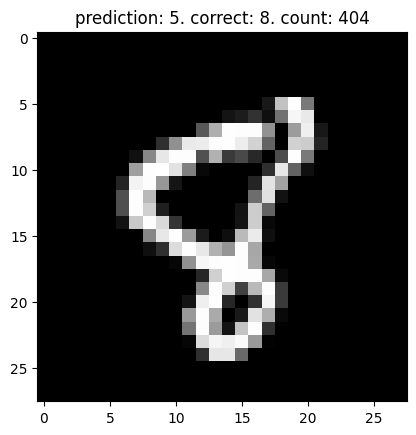

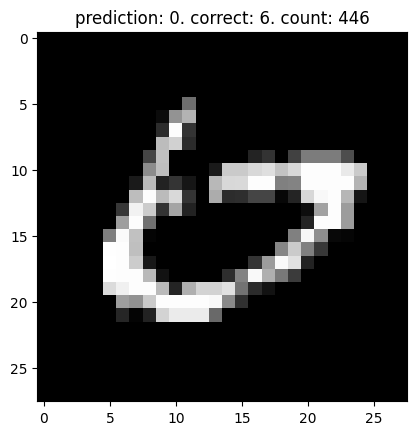

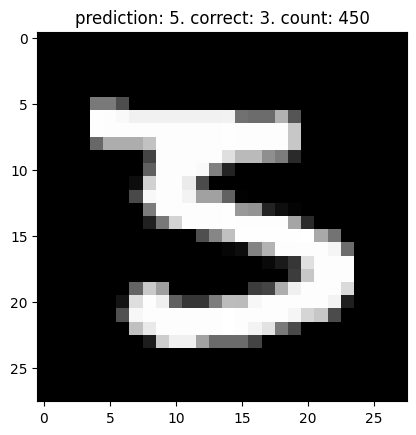

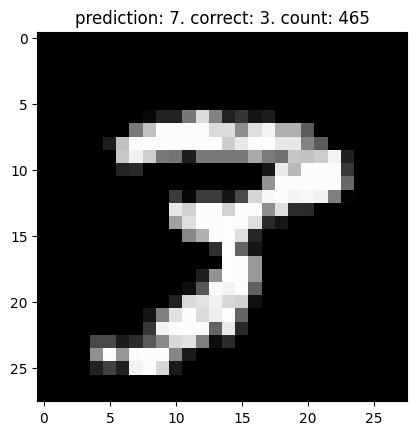

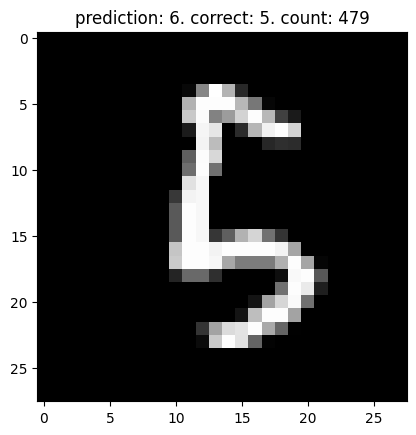

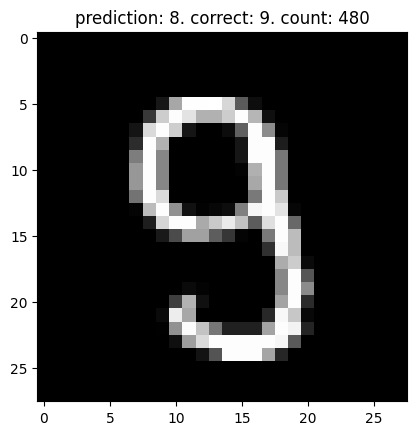

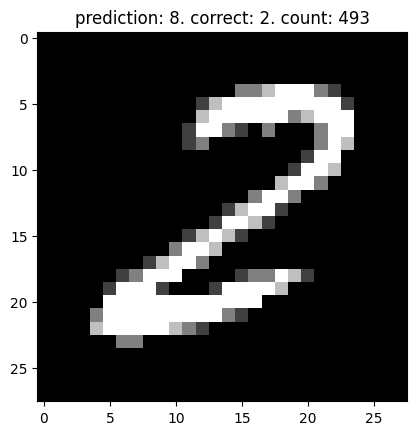

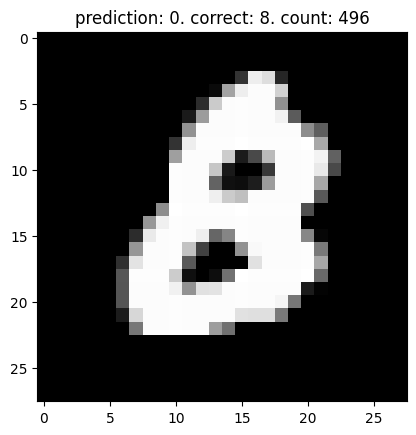

43
91.4


In [8]:
def predict(input, x_train, y_train, k):
    distances = []
    keys = []
    for i in range(len(x_train)):
        total = 0
        image = x_train[i].copy().flatten()
        for j in range(len(image)):
            total += abs(image[j]-input[j])**2

        if len(distances) < k:
            distances.append(total)
            keys.append(y_train[i])
        else:
            max_dist = max(distances)

            if max_dist > total:
                keys.pop(distances.index(max_dist))
                distances.remove(max_dist)

                keys.append(y_train[i])
                distances.append(total)
        
    map = {}
    most = 0
    val = 0
    for p in keys:
        if p not in map.keys():
            map[p] = 1
            if map[p] > most:
                most = map[p]
                val = p
        else:
            map[p] += 1
            if map[p] > most:
                most = map[p]
                val = p
    
    confidence = most/len(keys)
    prediction = val

    return prediction, confidence

correct = 0
k = 5
def quick_show():
    global correct
    count = 1
    for i in range(len(x_test)):
        prediction, confidence = predict(x_test[i].flatten(), x_train, y_train, k)
        if prediction == y_test[i]:
            correct+=1
        else:
            plt.imshow(x_test[i], cmap="gray")
            plt.title(f"prediction: {prediction}. correct: {y_test[i]}. count: {count}")
            plt.show()
        count+=1
quick_show()
accuracy = int(correct/len(x_test)*10000)/100
incorrect = len(x_test) - correct
print(incorrect)
print(accuracy)